# Gaussian linear regression: unbiased LOO by stratified path sampling

For each replicate, draw an index $i$ uniformly in $\{0,\ldots,n-1\}$ and estimate

$$
\log p(y_i \mid y_{-i}) = \int_0^1 \mathbb{E}_{\pi_{i,\lambda}}[\log p(y_i \mid \theta)]\,d\lambda,
$$

where $\pi_{i,0}(\theta)=p(\theta \mid y_{-i})$ and $\pi_{i,1}(\theta)=p(\theta \mid y)$. Multiplying by $n$ gives an unbiased estimator of the total LOO ELPD.


In [ ]:
from src import *

import numpy as np
import pandas as pd
import scipy.stats as stats
from scipy.integrate import quad
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="paper")
np.random.seed(2026)


## Simulated Gaussian linear model


In [ ]:
n, d = 40, 2
true_theta = np.array([2.5, -1.2])
X_data = np.random.randn(n, d)
sigma2_noise = 0.4**2
y_data = X_data @ true_theta + np.random.normal(0, np.sqrt(sigma2_noise), size=n)

prior_mean = np.zeros(d)
prior_cov = np.eye(d) * 10.0
prior_precision = np.linalg.inv(prior_cov)

blr_path = BayesianLinearRegressionTempering(
    X_data,
    y_data,
    prior_mean,
    prior_cov,
    sigma2_noise,
)



## `LOO with path sampling`

The path is the geometric path between the leave-one-out posterior and the full posterior:

$$
\pi_{i,\lambda}(\theta) \propto p(\theta\mid y_{-i})^{1-\lambda}p(\theta\mid y)^\lambda.
$$

Equivalently, up to normalizing constants,

$$
\pi_{i,\lambda}(\theta) \propto p(\theta)\prod_{j\ne i}p(y_j\mid\theta)\,p(y_i\mid\theta)^\lambda.
$$


In [14]:
loo_index = np.random.randint(n)


def log_target0(theta):
    """Unnormalized log posterior without observation loo_index."""
    return blr_path.log_posterior_minus_i(theta, loo_index)


def log_target1(theta):
    """Unnormalized full log posterior."""
    return blr_path.log_posterior_full(theta)


def log_target_path(theta, path):
    """Geometric path between p(theta | y_-i) and p(theta | y)."""
    return blr_path.log_path(theta, path, loo_index)


def grad_log_target_path(theta):
    """Derivative in lambda of log_target_path(theta, lambda)."""
    return log_target1(theta) - log_target0(theta)


In [15]:
L = 20  # 0, 0.1, ..., 1.0
nrep = 100
sigmaq = 1
lag = 1
lambda_grid = np.arange(0, L + 1) / L # uniform grid of lambda values in [0, 1]

Lambda grid: 100%|██████████| 21/21 [00:13<00:00,  1.50it/s]


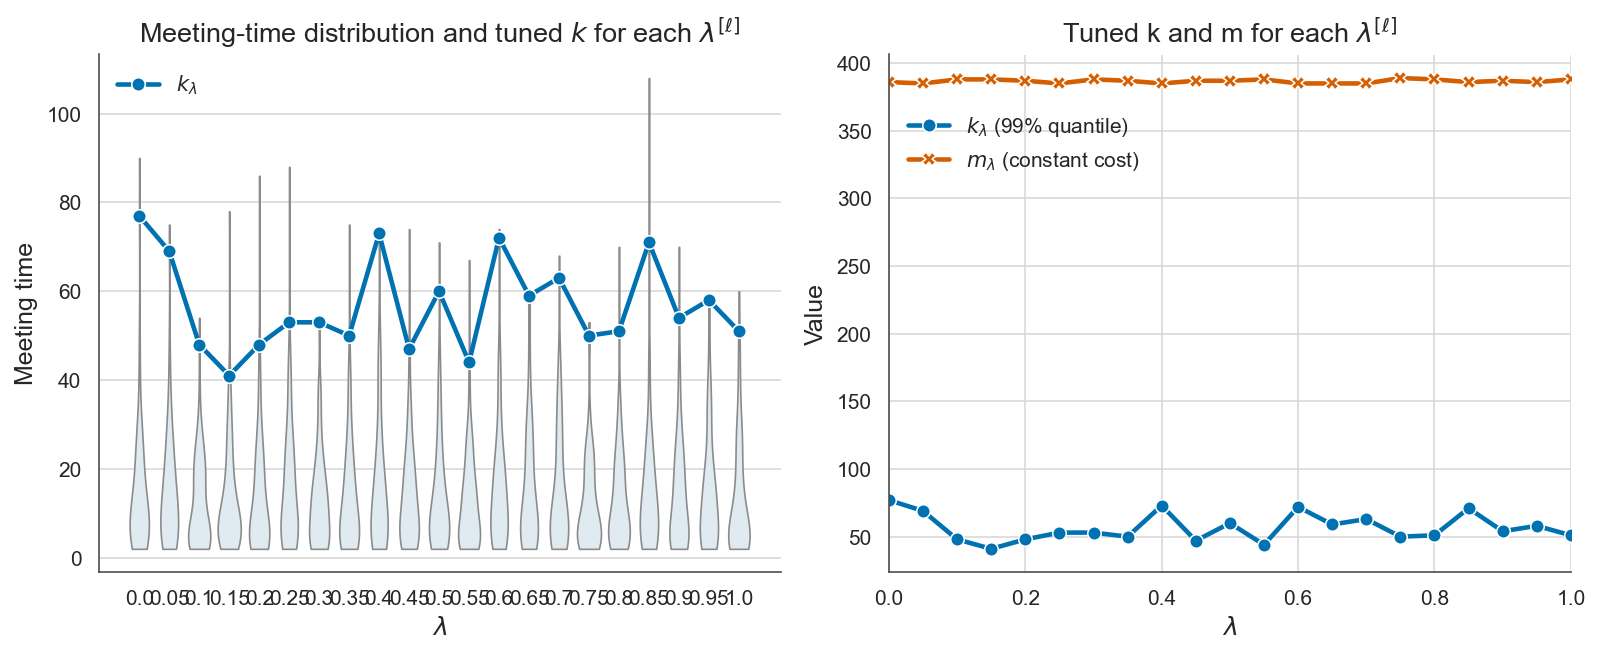

In [16]:
km_grid = tune_km_grid(lambda_grid, lag = lag, sigmaq = sigmaq, log_target_path = log_target_path, nrep = nrep)
plot_km_grid(lambda_grid, lag = lag, sigmaq = sigmaq, log_target_path = log_target_path, nrep = nrep)

Final estimation: 100%|██████████| 21/21 [09:37<00:00, 27.51s/it]


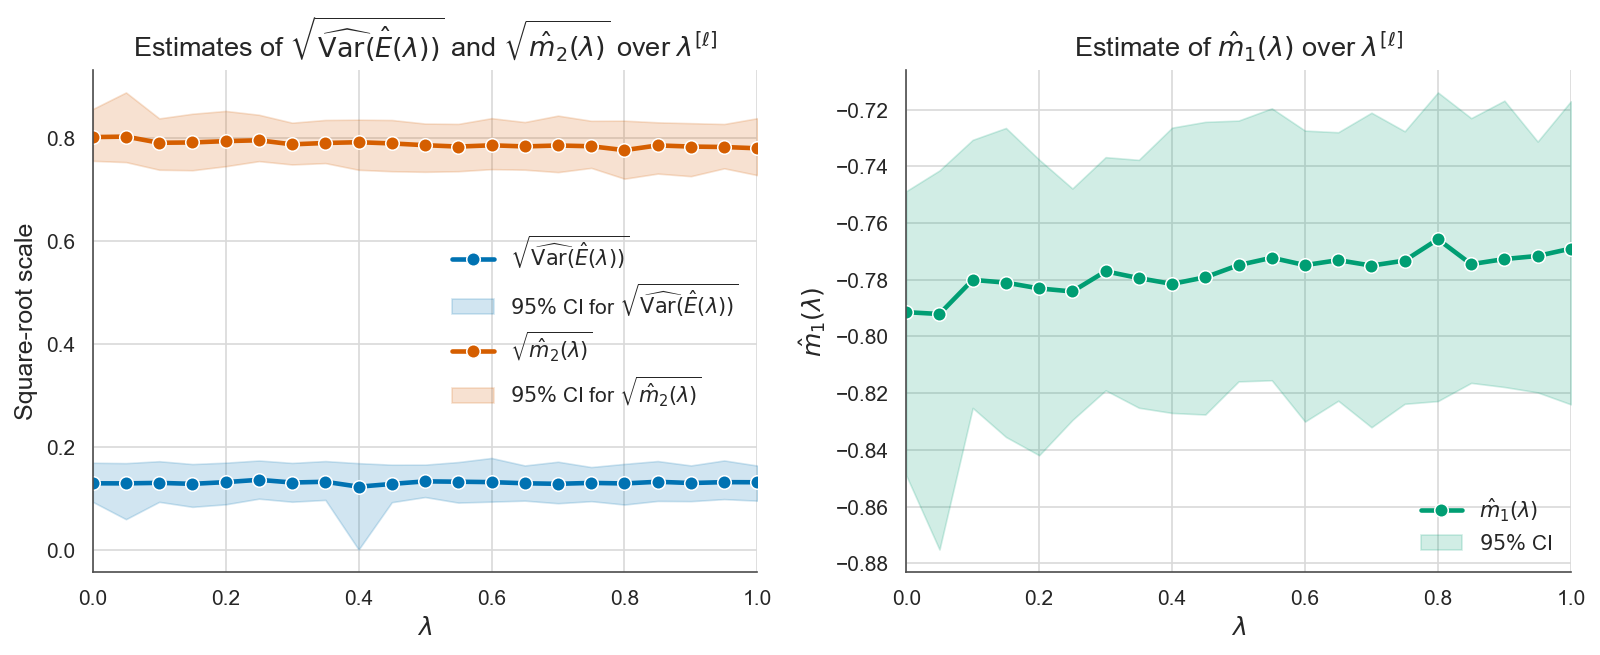

In [17]:
k_grid, m_grid = km_grid["k_grid"], km_grid["m_grid"]
plot_estimate_mom(lambda_grid, k_grid, m_grid, nrep, sigmaq, lag, log_target_path, grad_log_target_path)

In [ ]:
res = estimate_mom(lambda_grid, k_grid, m_grid, nrep, sigmaq, lag, log_target_path, grad_log_target_path)
sqrt_m2 = np.sqrt(res["m2"])

In [ ]:
M_grid = np.array([50, 100, 200]) # 500, 1000, 2000, 3000, 5000
for M in M_grid:

    estimates_opt = np.zeros(nrep)
    for _ in range(nrep):
        for i in range(M):

            st_loo =0

            loo_index = np.random.randint(n)
            log_target_path_i = lambda theta, path, i=loo_index: blr_path.log_path(theta, path, i)
            grad_log_target_path_i = lambda theta, i=loo_index: blr_path.log_posterior_full(theta) - blr_path.log_posterior_minus_i(theta, i)
            estimator_i = lambda lam: uestimator_given_lambda(lam, lambda_grid, k_grid, m_grid, sigmaq, lag, log_target_path_i, grad_log_target_path_i)
            budget = build_budget(
            L=L,
            M=M,
            estimator=estimator_i,
            n_samples_per_bin=10,
        )
            st_loo += optimal_startified_estimator(L, estimator_i, budget)/M
        estimates_opt.append(st_loo)
plt.plot(M_grid, estimates_opt)
        








In [18]:
M_grid = np.array([50, 100, 200])  # 500, 1000, 2000, 3000, 5000
nrep = 10

mean_estimates_opt = np.zeros(len(M_grid))
mse_estimates_opt = np.zeros(len(M_grid))

for m_idx, M in enumerate(M_grid):
    estimates_opt = np.zeros(nrep)

    for r in range(nrep):
        st_loo = 0.0

        for _ in range(M):
            loo_index = np.random.randint(n)

            log_target_path_i = lambda theta, path, i=loo_index: blr_path.log_path(
                theta,
                path,
                i,
            )

            grad_log_target_path_i = lambda theta, i=loo_index: (
                blr_path.log_posterior_full(theta)
                - blr_path.log_posterior_minus_i(theta, i)
            )

            estimator_i = lambda lam: uestimator_given_lambda(
                lam,
                lambda_grid,
                k_grid,
                m_grid,
                sigmaq,
                lag,
                log_target_path_i,
                grad_log_target_path_i,
            )

            budget = build_budget(
                L=L,
                M=M,
                estimator=estimator_i,
                n_samples_per_bin=10,
            )

            st_loo += n * optimal_startified_estimator(
                L,
                estimator_i,
                budget,
            ) / M

        estimates_opt[r] = st_loo

    mean_estimates_opt[m_idx] = np.mean(estimates_opt)
    mse_estimates_opt[m_idx] = np.mean((estimates_opt - true_value) ** 2)

plt.figure(figsize=(7, 4.5), dpi=150)
plt.plot(M_grid, mse_estimates_opt, marker="o", linewidth=2)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Budget M")
plt.ylabel("MSE")
plt.title("MSE of stratified LOO estimator")
plt.grid(True, which="both", alpha=0.4)
plt.tight_layout()
plt.show()

KeyboardInterrupt: 